# 🌦️ Nepal Weather Data — Exploratory Data Analysis (EDA)
**Data:** 10 major Nepal cities | Sep 2025 – Mar 2026 | Source: Open-Meteo API + BeautifulSoup  
**Goal:** Understand temperature trends, rainfall patterns, wind, and weather conditions before building prediction models.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Plot style
sns.set_theme(style="whitegrid", palette="husl")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"]     = 100

print("✅ Libraries loaded")

✅ Libraries loaded


## 2. Load & Clean Data

In [2]:
# Load raw CSV
df_raw = pd.read_csv("nepal_weather_data.csv")
print(f"Raw shape: {df_raw.shape}")
print(f"Sources:\n{df_raw['source'].value_counts()}\n")

# ── Use only Open-Meteo rows (complete data for EDA & ML) ──────────────────────
df = df_raw[df_raw["source"] == "Open-Meteo_API"].copy()

# Fix types
df["date"]             = pd.to_datetime(df["date"])
df["temp_max_c"]       = pd.to_numeric(df["temp_max_c"],       errors="coerce")
df["temp_min_c"]       = pd.to_numeric(df["temp_min_c"],       errors="coerce")
df["temperature"]      = pd.to_numeric(df["temperature"],      errors="coerce")
df["precipitation_mm"] = pd.to_numeric(df["precipitation_mm"], errors="coerce")
df["wind_speed_max"]   = pd.to_numeric(df["wind_speed_max"],   errors="coerce")

# Add time features
df["month"]      = df["date"].dt.month
df["month_name"] = df["date"].dt.strftime("%b")
df["day_of_week"]= df["date"].dt.day_name()
df["temp_range"] = df["temp_max_c"] - df["temp_min_c"]

df = df.sort_values(["city", "date"]).reset_index(drop=True)

print(f"Clean shape: {df.shape}")
print(f"Cities: {df['city'].nunique()} → {sorted(df['city'].unique())}")
print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")
df.head()

Raw shape: (1959, 9)
Sources:
source
Open-Meteo_API    1920
BeautifulSoup       39
Name: count, dtype: int64

Clean shape: (1920, 13)
Cities: 10 → ['Bharatpur', 'Biratnagar', 'Birgunj', 'Butwal', 'Dhangadhi', 'Dharan', 'Janakpur', 'Kathmandu', 'Nepalgunj', 'Pokhara']
Date range: 2025-09-01 → 2026-03-11


,city,date,temp_max_c,temp_min_c,temperature,precipitation_mm,wind_speed_max,condition,source,month,month_name,day_of_week,temp_range
0,Bharatpur,2025-09-01,34.2,23.9,28.6,0.0,8.3,Overcast,Open-Meteo_API,9,Sep,Monday,10.3
1,Bharatpur,2025-09-02,33.5,24.0,28.4,0.5,8.5,Moderate drizzle,Open-Meteo_API,9,Sep,Tuesday,9.5
2,Bharatpur,2025-09-03,33.8,24.6,28.8,0.2,9.0,Light drizzle,Open-Meteo_API,9,Sep,Wednesday,9.2
3,Bharatpur,2025-09-04,33.7,25.0,28.8,2.1,6.7,Dense drizzle,Open-Meteo_API,9,Sep,Thursday,8.7
4,Bharatpur,2025-09-05,33.0,24.6,28.5,0.8,7.3,Light drizzle,Open-Meteo_API,9,Sep,Friday,8.4


## 3. Explore Data Structure

In [3]:
print("── Data types ──────────────────────────────")
print(df.dtypes)
print("\n── Missing values ──────────────────────────")
print(df.isnull().sum())
print("\n── Descriptive Statistics ──────────────────")
df[["temp_max_c","temp_min_c","temperature","precipitation_mm","wind_speed_max","temp_range"]].describe().round(2)

── Data types ──────────────────────────────
city                        object
date                datetime64[ns]
temp_max_c                 float64
temp_min_c                 float64
temperature                float64
precipitation_mm           float64
wind_speed_max             float64
condition                   object
source                      object
month                        int32
month_name                  object
day_of_week                 object
temp_range                 float64
dtype: object

── Missing values ──────────────────────────
city                0
date                0
temp_max_c          0
temp_min_c          0
temperature         0
precipitation_mm    0
wind_speed_max      0
condition           0
source              0
month               0
month_name          0
day_of_week         0
temp_range          0
dtype: int64

── Descriptive Statistics ──────────────────


,temp_max_c,temp_min_c,temperature,precipitation_mm,wind_speed_max,temp_range
count,1920.00,1920.00,1920.00,1920.00,1920.00,1920.00
mean,25.03,14.66,19.27,2.08,9.29,10.38
std,4.81,5.95,5.34,8.46,3.48,2.96
min,13.20,1.90,8.30,0.00,3.00,1.00
25%,21.20,10.00,14.80,0.00,7.00,8.40
50%,25.00,13.30,18.80,0.00,8.70,10.70
75%,29.00,20.00,24.10,0.10,10.72,12.60
max,36.50,27.40,30.80,138.90,57.00,18.20


In [4]:
# Per-city summary
city_stats = df.groupby("city").agg(
    avg_temp      = ("temperature",      "mean"),
    max_temp      = ("temp_max_c",       "max"),
    min_temp      = ("temp_min_c",       "min"),
    avg_rain      = ("precipitation_mm", "mean"),
    total_rain    = ("precipitation_mm", "sum"),
    avg_wind      = ("wind_speed_max",   "mean"),
    days_recorded = ("date",             "count")
).round(2).sort_values("avg_temp", ascending=False)

print("── Per-City Summary ────────────────────────")
city_stats

── Per-City Summary ────────────────────────


,avg_temp,max_temp,min_temp,avg_rain,total_rain,avg_wind,days_recorded
city,,,,,,,
Biratnagar,21.26,34.8,8.6,2.51,482.4,10.85,192
Janakpur,20.79,35.8,7.1,2.56,491.2,11.28,192
Dharan,20.62,35.1,8.8,1.90,365.1,9.86,192
Birgunj,20.50,34.5,6.3,2.15,412.5,10.88,192
Bharatpur,20.28,36.5,4.8,1.78,341.7,6.89,192
Dhangadhi,19.27,34.8,5.7,1.59,305.5,8.82,192
Nepalgunj,19.21,34.2,5.1,1.44,276.2,9.21,192
Butwal,19.04,33.2,5.4,1.46,279.6,8.19,192
Pokhara,16.17,31.2,3.8,2.53,485.6,8.45,192


## 4. Temperature Trends Over Time

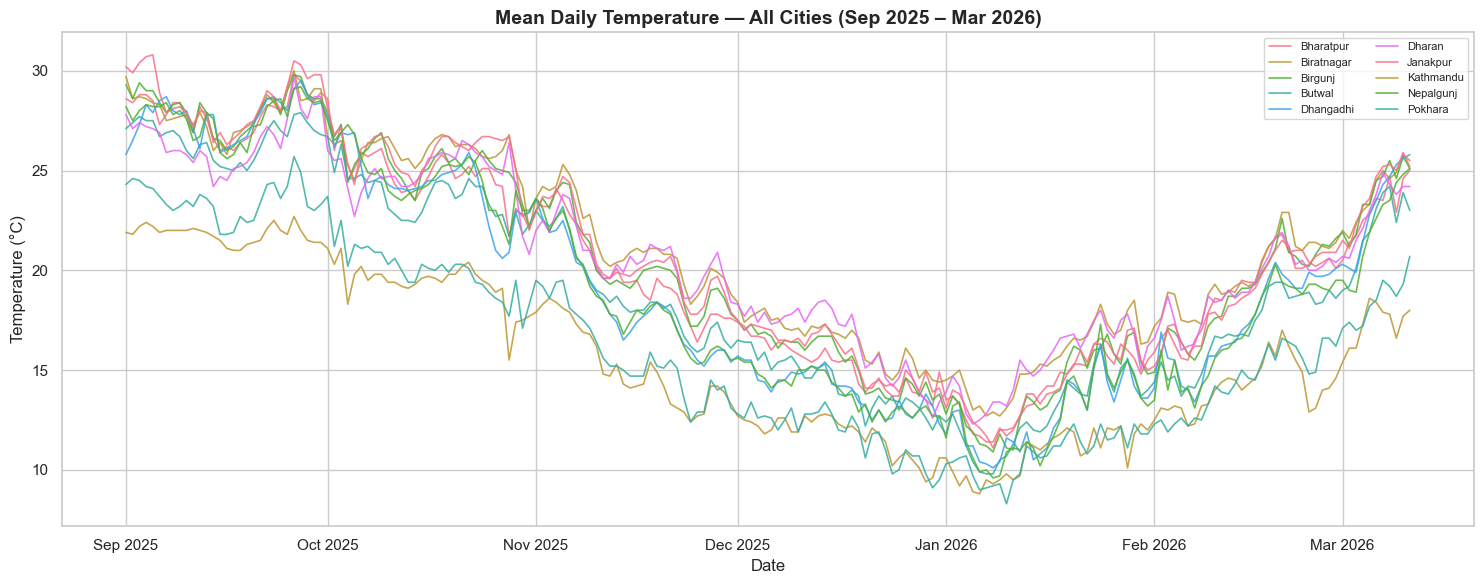

In [5]:
# Mean temperature over time — all cities
fig, ax = plt.subplots(figsize=(15, 6))
for city, grp in df.groupby("city"):
    ax.plot(grp["date"], grp["temperature"], linewidth=1.2, label=city, alpha=0.85)

ax.set_title("Mean Daily Temperature — All Cities (Sep 2025 – Mar 2026)", fontsize=14, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (°C)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.legend(loc="upper right", fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

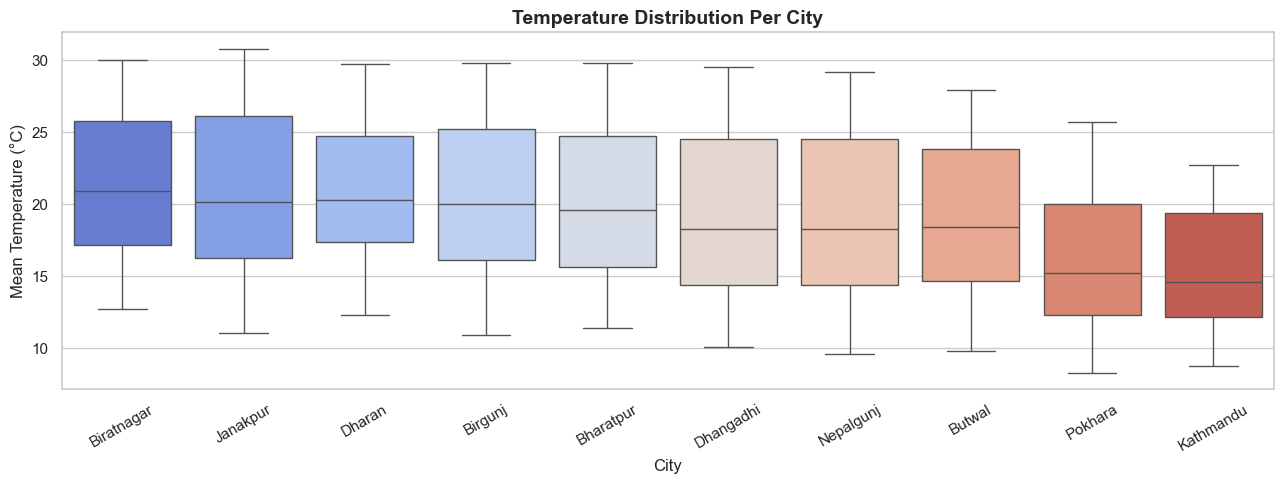

In [6]:

# Temperature range (max - min) per city — boxplot
fig, ax = plt.subplots(figsize=(13, 5))
order = df.groupby("city")["temperature"].mean().sort_values(ascending=False).index
sns.boxplot(data=df, x="city", y="temperature", order=order, palette="coolwarm", ax=ax)
ax.set_title("Temperature Distribution Per City", fontsize=14, fontweight="bold")
ax.set_xlabel("City")
ax.set_ylabel("Mean Temperature (°C)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## 5. Rainfall Analysis

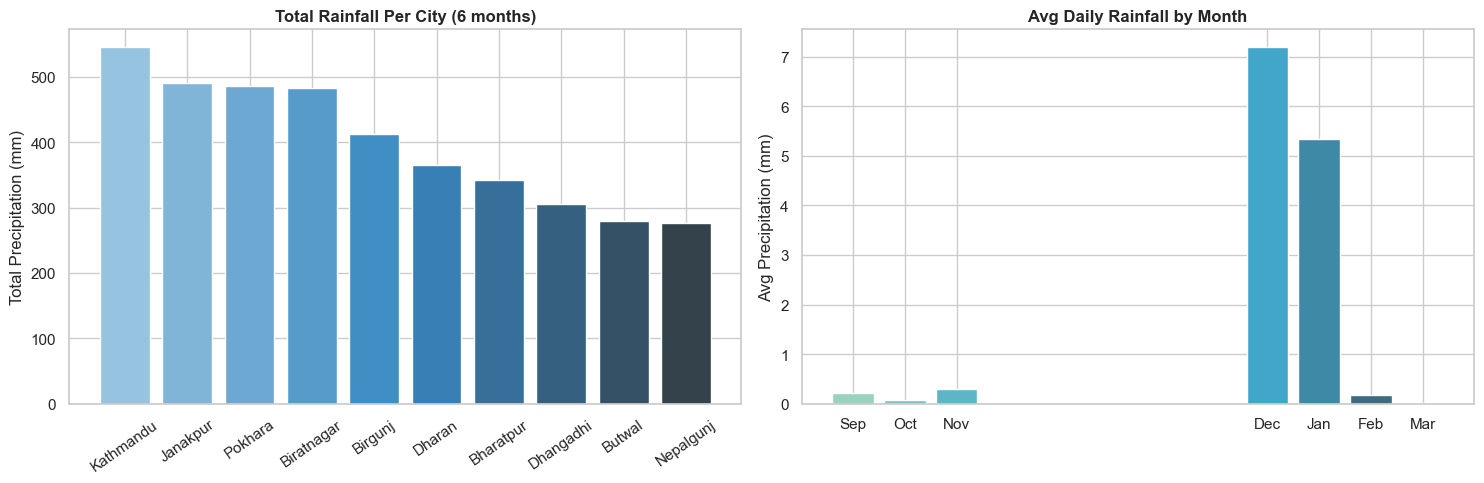

In [7]:

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Total rainfall per city
rain_city = df.groupby("city")["precipitation_mm"].sum().sort_values(ascending=False)
axes[0].bar(rain_city.index, rain_city.values, color=sns.color_palette("Blues_d", len(rain_city)))
axes[0].set_title("Total Rainfall Per City (6 months)", fontweight="bold")
axes[0].set_ylabel("Total Precipitation (mm)")
axes[0].tick_params(axis="x", rotation=35)

# Monthly average rainfall — all cities combined
monthly_rain = df.groupby("month")["precipitation_mm"].mean()
month_labels = ["Sep","Oct","Nov","Dec","Jan","Feb","Mar"]
axes[1].bar(monthly_rain.index, monthly_rain.values, color=sns.color_palette("GnBu_d", 7))
axes[1].set_title("Avg Daily Rainfall by Month", fontweight="bold")
axes[1].set_ylabel("Avg Precipitation (mm)")
axes[1].set_xticks(monthly_rain.index)
axes[1].set_xticklabels(month_labels)

plt.tight_layout()
plt.show()


## 6. Wind Speed Analysis

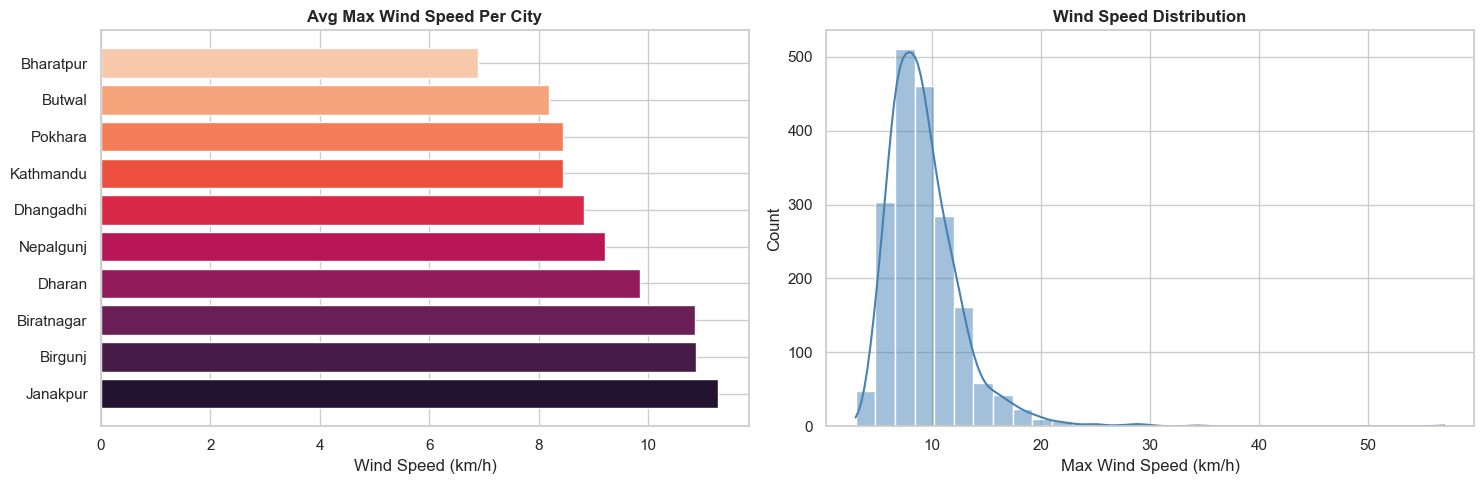

In [8]:

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Avg wind speed per city
wind_city = df.groupby("city")["wind_speed_max"].mean().sort_values(ascending=False)
axes[0].barh(wind_city.index, wind_city.values, color=sns.color_palette("rocket", len(wind_city)))
axes[0].set_title("Avg Max Wind Speed Per City", fontweight="bold")
axes[0].set_xlabel("Wind Speed (km/h)")

# Wind speed distribution
sns.histplot(df["wind_speed_max"].dropna(), bins=30, kde=True, color="steelblue", ax=axes[1])
axes[1].set_title("Wind Speed Distribution", fontweight="bold")
axes[1].set_xlabel("Max Wind Speed (km/h)")

plt.tight_layout()
plt.show()


## 7. Weather Conditions

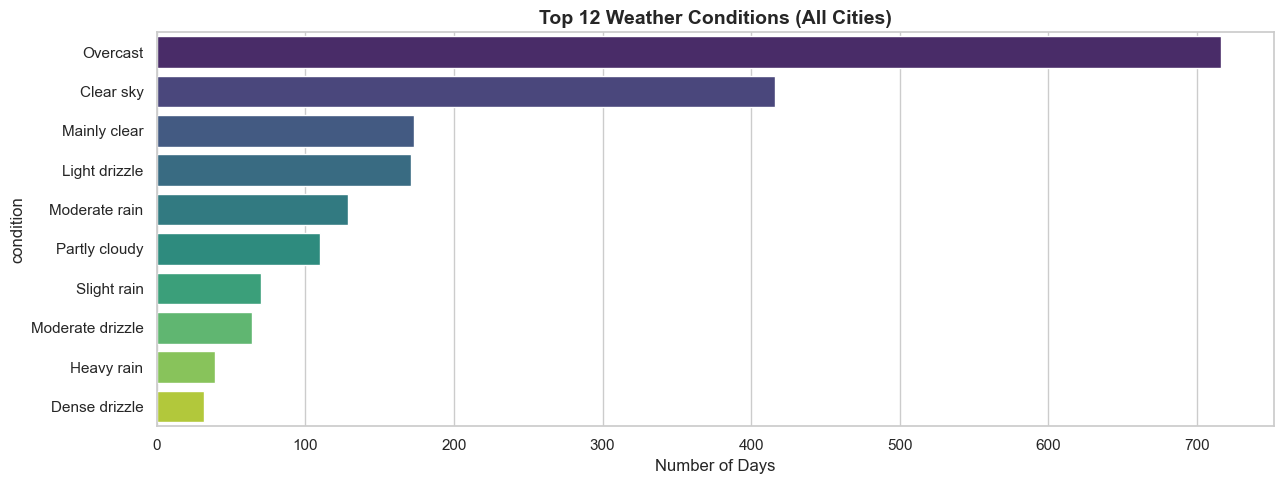

In [9]:

# Top weather conditions — all cities
fig, ax = plt.subplots(figsize=(13, 5))
cond_counts = df["condition"].value_counts().head(12)
sns.barplot(x=cond_counts.values, y=cond_counts.index, palette="viridis", ax=ax)
ax.set_title("Top 12 Weather Conditions (All Cities)", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of Days")
plt.tight_layout()
plt.show()


## 8. Correlation Heatmap

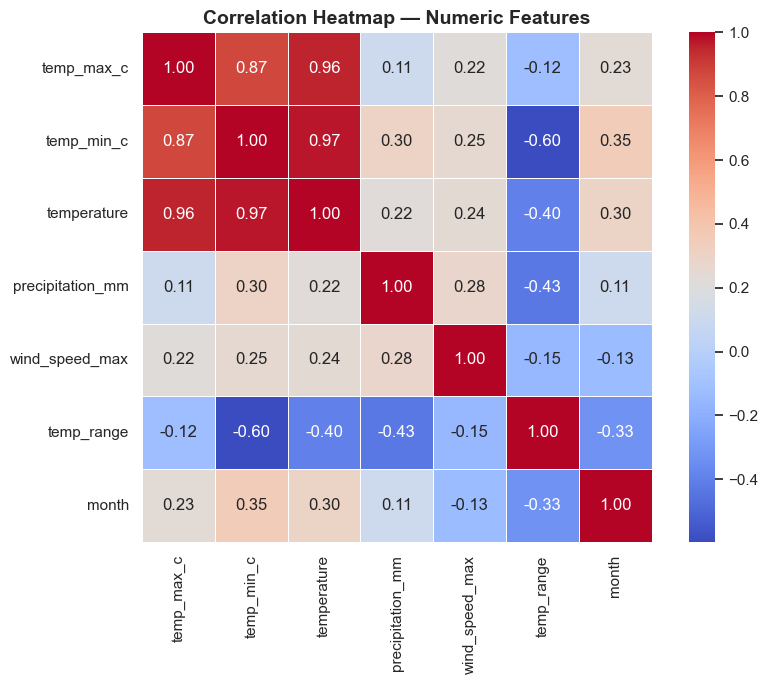

In [10]:

num_cols = ["temp_max_c", "temp_min_c", "temperature", "precipitation_mm", "wind_speed_max", "temp_range", "month"]
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Correlation Heatmap — Numeric Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


## 9. Monthly Temperature Heatmap (City × Month)

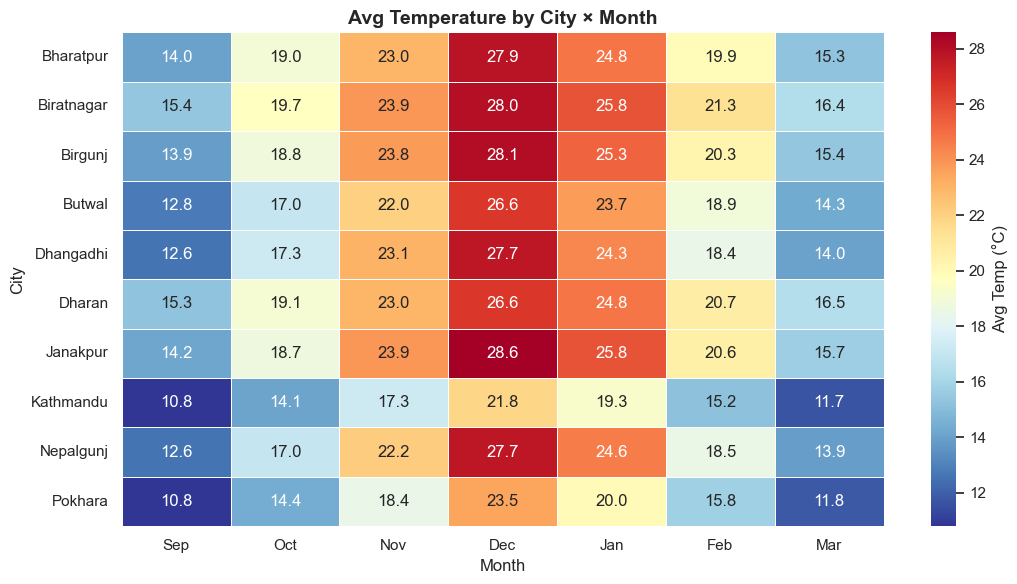

In [11]:

pivot = df.pivot_table(values="temperature", index="city", columns="month", aggfunc="mean").round(1)
pivot.columns = ["Sep","Oct","Nov","Dec","Jan","Feb","Mar"]

fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="RdYlBu_r",
            linewidths=0.5, ax=ax, cbar_kws={"label": "Avg Temp (°C)"})
ax.set_title("Avg Temperature by City × Month", fontsize=14, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("City")
plt.tight_layout()
plt.show()


## 10. Key Findings Summary

In [12]:

print("=" * 55)
print("📊 EDA KEY FINDINGS")
print("=" * 55)
print(f"📅 Date range   : {df['date'].min().date()} → {df['date'].max().date()}")
print(f"🏙️  Cities        : {df['city'].nunique()} ({', '.join(sorted(df['city'].unique()))})")
print(f"📈 Total rows    : {len(df)}")
print()
hottest  = city_stats["avg_temp"].idxmax()
coldest  = city_stats["avg_temp"].idxmin()
rainiest = city_stats["total_rain"].idxmax()
windiest = city_stats["avg_wind"].idxmax()
print(f"🌡️  Hottest city  : {hottest}  ({city_stats.loc[hottest,'avg_temp']:.1f}°C avg)")
print(f"🧊 Coldest city  : {coldest}  ({city_stats.loc[coldest,'avg_temp']:.1f}°C avg)")
print(f"🌧️  Most rainfall : {rainiest}  ({city_stats.loc[rainiest,'total_rain']:.0f} mm total)")
print(f"💨 Windiest city : {windiest}  ({city_stats.loc[windiest,'avg_wind']:.1f} km/h avg)")
print()
print(f"🌡️  Overall temp range : {df['temp_min_c'].min():.1f}°C → {df['temp_max_c'].max():.1f}°C")
print(f"☔ Rainy days (>1mm) : {(df['precipitation_mm'] > 1).sum()} / {len(df)}")
print(f"⛈️  Top condition     : {df['condition'].value_counts().index[0]}")
print("=" * 55)
print("✅ EDA complete — ready for ml_prediction.ipynb")


📊 EDA KEY FINDINGS
📅 Date range   : 2025-09-01 → 2026-03-11
🏙️  Cities        : 10 (Bharatpur, Biratnagar, Birgunj, Butwal, Dhangadhi, Dharan, Janakpur, Kathmandu, Nepalgunj, Pokhara)
📈 Total rows    : 1920

🌡️  Hottest city  : Biratnagar  (21.3°C avg)
🧊 Coldest city  : Kathmandu  (15.6°C avg)
🌧️  Most rainfall : Kathmandu  (545 mm total)
💨 Windiest city : Janakpur  (11.3 km/h avg)

🌡️  Overall temp range : 1.9°C → 36.5°C
☔ Rainy days (>1mm) : 335 / 1920
⛈️  Top condition     : Overcast
✅ EDA complete — ready for ml_prediction.ipynb
